# Compare raw vs reconstructed nEMG signals for two checkpoints

This notebook:

1. loads **two** saved checkpoints,
2. builds one `EMGWindowDataset` from one split CSV,
3. filters samples by label (`ALS`, `Normal`, or `Myopathy`),
4. picks the same random samples for both checkpoints,
5. reconstructs them with both models, and
6. plots and summarizes the reconstruction error side by side.

It supports the three VAE checkpoints used in this repo:

- `simple_vae`
- `conv1d_beta_vae`
- `van_de_leur_model`

For repeatable plots, reconstruction defaults to **deterministic decoding from `mu`**
instead of stochastic sampling from the latent distribution.


In [3]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


## 1) Set your paths, labels, and sampling options


In [4]:

# ---- USER SETTINGS ----
# Leave REPO_ROOT as None if you run this notebook somewhere inside the repo.
REPO_ROOT = None

CHECKPOINT_PATH_A = Path("multirun/van_de_leur_model_weighted_huber/2026-04-02/20-32-09/0/checkpoints/best.pt")
CHECKPOINT_PATH_B = Path("multirun/van_de_leur_model_betas_huber/2026-04-02/22-25-06/1/checkpoints/last.pt")
CHECKPOINT_LABEL_A = "Weighted_Hubers_cosine_loss"
CHECKPOINT_LABEL_B = "Weighted_Hubers_cosine_loss_beta_vae"

SPLIT_CSV = Path("data/emglab/splits/fold_0/val.csv")
WINDOWS_DIR = Path("data/emglab/windows_w100_h100")

USE_DOWNSAMPLED = False
MODEL_KIND_A = "auto"   # "auto", "simple_vae", "conv1d_beta_vae", or "van_de_leur_model"
MODEL_KIND_B = "auto"   # "auto", "simple_vae", "conv1d_beta_vae", or "van_de_leur_model"
TARGET_LABEL = "Myopathy"  # "ALS", "Normal", "Myopathy", or 0/1/2
NUM_RANDOM_SAMPLES = 3
RANDOM_SEED = 42

DETERMINISTIC_RECON = True  # True = decode(mu), False = standard stochastic VAE forward
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


## 2) Repo import setup

In [5]:
def find_repo_root(explicit_root: str | Path | None = None) -> Path:
    if explicit_root is not None:
        root = Path(explicit_root).expanduser().resolve()
        if not (root / "nemg" / "dataset" / "dataset.py").exists():
            raise FileNotFoundError(f"Could not find nemg package under {root}")
        return root

    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "nemg" / "dataset" / "dataset.py").exists():
            return candidate

    raise FileNotFoundError(
        "Could not auto-detect the repo root. "
        "Set REPO_ROOT manually to the folder that contains the 'nemg' directory."
    )

repo_root = find_repo_root(REPO_ROOT)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)
print("Device:", DEVICE)

Repo root: /gpfs/home4/awibisono1/FactorEMG
Device: cpu


## 3) Imports from the repo

In [6]:
from nemg.dataset.dataset import EMGWindowDataset, LABEL_TO_INT
from nemg.experiments.simple_vae.model import SimpleVAE
from nemg.experiments.conv1d_beta_vae.model import Conv1DBetaVAE as Conv1DBetaVAEOriginal
from nemg.experiments.van_de_leur_model.model import Conv1DBetaVAE as VanDeLeurConv1DBetaVAE

INT_TO_LABEL = {v: k for k, v in LABEL_TO_INT.items()}
INT_TO_LABEL

{0: 'ALS', 1: 'Normal', 2: 'Myopathy'}

## 4) Helpers for loading, reconstructing, and comparing checkpoints


In [7]:

def resolve_path(path_like: str | Path, base: Path) -> Path:
    path = Path(path_like).expanduser()
    return path if path.is_absolute() else (base / path).resolve()


def normalize_label(label: str | int) -> int:
    if isinstance(label, str):
        if label not in LABEL_TO_INT:
            raise ValueError(f"Unknown label '{label}'. Known labels: {list(LABEL_TO_INT)}")
        return LABEL_TO_INT[label]
    label = int(label)
    if label not in INT_TO_LABEL:
        raise ValueError(f"Unknown label id {label}. Known ids: {list(INT_TO_LABEL)}")
    return label


def normalize_model_kind(model_kind: str) -> str:
    aliases = {
        "van_de_leur": "van_de_leur_model",
        "van_de_leur_model": "van_de_leur_model",
        "simple_vae": "simple_vae",
        "conv1d_beta_vae": "conv1d_beta_vae",
        "auto": "auto",
    }
    if model_kind not in aliases:
        raise ValueError(
            f"Unknown MODEL_KIND '{model_kind}'. "
            "Use one of: auto, simple_vae, conv1d_beta_vae, van_de_leur_model."
        )
    return aliases[model_kind]


def infer_model_kind(checkpoint: dict, model_kind: str = "auto") -> str:
    model_kind = normalize_model_kind(model_kind)
    if model_kind != "auto":
        return model_kind

    cfg = checkpoint.get("cfg", {}) or {}
    model_cfg = cfg.get("model", {}) or {}

    if {"hidden_dim_1", "hidden_dim_2"} <= set(model_cfg):
        return "simple_vae"
    if {"depth", "reduced_size", "decoder_in_channels"} <= set(model_cfg):
        return "van_de_leur_model"
    if {"channels", "hidden_dim", "kernel_size", "stride"} <= set(model_cfg):
        return "conv1d_beta_vae"

    state_keys = set(checkpoint["model_state_dict"].keys())
    if any(k.startswith("encoder.network.") for k in state_keys):
        return "van_de_leur_model"
    if any(k.startswith("fc_hidden") for k in state_keys):
        return "conv1d_beta_vae"
    if any(k.startswith("encoder.0.weight") for k in state_keys):
        return "simple_vae"

    raise ValueError(
        "Could not infer model type from checkpoint. "
        "Set MODEL_KIND manually to 'simple_vae', 'conv1d_beta_vae', or 'van_de_leur_model'."
    )


def build_model_from_checkpoint(checkpoint: dict, model_kind: str = "auto") -> tuple[torch.nn.Module, str]:
    kind = infer_model_kind(checkpoint, model_kind=model_kind)
    cfg = checkpoint.get("cfg", {}) or {}
    model_cfg = cfg.get("model", {}) or {}
    input_dim = int(checkpoint["input_dim"])

    if kind == "simple_vae":
        model = SimpleVAE(
            input_dim=input_dim,
            latent_dim=int(model_cfg.get("latent_dim", 16)),
            hidden_dim_1=int(model_cfg.get("hidden_dim_1", 512)),
            hidden_dim_2=int(model_cfg.get("hidden_dim_2", 128)),
        )
    elif kind == "conv1d_beta_vae":
        model = Conv1DBetaVAEOriginal(
            input_dim=input_dim,
            latent_dim=int(model_cfg.get("latent_dim", 16)),
            channels=tuple(model_cfg.get("channels", [32, 64, 128])),
            kernel_size=int(model_cfg.get("kernel_size", 7)),
            stride=int(model_cfg.get("stride", 2)),
            hidden_dim=int(model_cfg.get("hidden_dim", 128)),
        )
    elif kind == "van_de_leur_model":
        channels = model_cfg.get("channels", 128)
        if isinstance(channels, (list, tuple)):
            if len(channels) != 1:
                raise ValueError(
                    "van_de_leur_model expects cfg.model.channels to be a single integer, "
                    f"but got {channels}"
                )
            channels = channels[0]

        model = VanDeLeurConv1DBetaVAE(
            input_dim=input_dim,
            latent_dim=int(model_cfg.get("latent_dim", 21)),
            channels=int(channels),
            depth=int(model_cfg.get("depth", 7)),
            reduced_size=int(model_cfg.get("reduced_size", 64)),
            decoder_in_channels=int(model_cfg.get("decoder_in_channels", 64)),
            kernel_size=int(model_cfg.get("kernel_size", 5)),
            softplus_eps=float(model_cfg.get("softplus_eps", 1.0e-4)),
            dropout=float(model_cfg.get("dropout", 0.0)),
            gaussian_out=bool(model_cfg.get("gaussian_out", True)),
        )
    else:
        raise ValueError(f"Unsupported model kind: {kind}")

    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    return model, kind


def load_checkpoint_model(checkpoint_path: str | Path, model_kind: str = "auto", device: str = "cpu"):
    checkpoint_path = resolve_path(checkpoint_path, repo_root)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model, inferred_kind = build_model_from_checkpoint(checkpoint, model_kind=model_kind)
    model = model.to(device).eval()
    return checkpoint, model, inferred_kind, checkpoint_path


def build_dataset(split_csv: str | Path, windows_dir: str | Path, use_downsampled: bool = False) -> EMGWindowDataset:
    split_csv = resolve_path(split_csv, repo_root)
    windows_dir = resolve_path(windows_dir, repo_root)
    dataset = EMGWindowDataset.from_csv(
        csv_path=split_csv,
        windows_dir=windows_dir,
        use_downsampled=use_downsampled,
        cache=True,
    )
    return dataset


def label_distribution(dataset: EMGWindowDataset) -> dict[str, int]:
    counts = Counter(dataset.labels)
    return {INT_TO_LABEL[k]: counts.get(k, 0) for k in sorted(INT_TO_LABEL)}


def sample_indices_for_label(
    dataset: EMGWindowDataset,
    target_label: str | int,
    n_samples: int,
    seed: int | None = None,
) -> list[int]:
    target_label_int = normalize_label(target_label)
    matching_indices = [idx for idx, label in enumerate(dataset.labels) if label == target_label_int]

    if not matching_indices:
        raise ValueError(f"No samples found for label '{target_label}' ({target_label_int}).")

    rng = random.Random(seed)
    n_samples = min(n_samples, len(matching_indices))
    return rng.sample(matching_indices, k=n_samples)


@torch.no_grad()
def reconstruct_batch(
    model: torch.nn.Module,
    batch_x: torch.Tensor,
    device: str = "cpu",
    deterministic: bool = True,
) -> torch.Tensor:
    batch_x = batch_x.to(device).float()
    model.eval()

    if deterministic and hasattr(model, "encode") and hasattr(model, "decode"):
        mu, _ = model.encode(batch_x)
        x_hat = model.decode(mu)
    else:
        x_hat, *_ = model(batch_x)

    return x_hat.detach().cpu()


def fetch_samples(dataset: EMGWindowDataset, indices: list[int]) -> tuple[torch.Tensor, torch.Tensor]:
    xs, ys = [], []
    for idx in indices:
        x, y = dataset[idx]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs, dim=0), torch.tensor(ys)


def reconstruction_mse_per_sample(raw_batch: torch.Tensor, recon_batch: torch.Tensor) -> np.ndarray:
    raw_np = raw_batch.detach().cpu().numpy()
    recon_np = recon_batch.detach().cpu().numpy()
    return ((raw_np - recon_np) ** 2).mean(axis=1)


def summarize_checkpoint(label: str, checkpoint_path: Path, checkpoint: dict, model_kind: str, model: torch.nn.Module) -> dict:
    return {
        "label": label,
        "path": str(checkpoint_path),
        "model_kind": model_kind,
        "epoch": checkpoint.get("epoch"),
        "input_dim": checkpoint.get("input_dim"),
        "num_parameters": sum(p.numel() for p in model.parameters()),
        "num_trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }


def compare_model_weights(model_a: torch.nn.Module, model_b: torch.nn.Module) -> dict:
    state_a = model_a.state_dict()
    state_b = model_b.state_dict()

    keys_a = list(state_a.keys())
    keys_b = list(state_b.keys())
    if keys_a != keys_b:
        missing_in_b = sorted(set(keys_a) - set(keys_b))
        missing_in_a = sorted(set(keys_b) - set(keys_a))
        return {
            "comparable": False,
            "reason": "state_dict keys differ",
            "missing_in_b": missing_in_b[:10],
            "missing_in_a": missing_in_a[:10],
        }

    total_params = 0
    sum_abs_diff = 0.0
    sum_sq_diff = 0.0
    max_abs_diff = 0.0

    for key in keys_a:
        tensor_a = state_a[key].detach().float().cpu()
        tensor_b = state_b[key].detach().float().cpu()
        if tensor_a.shape != tensor_b.shape:
            return {
                "comparable": False,
                "reason": f"shape mismatch for key '{key}'",
            }
        diff = tensor_a - tensor_b
        abs_diff = diff.abs()
        total_params += diff.numel()
        sum_abs_diff += float(abs_diff.sum().item())
        sum_sq_diff += float((diff ** 2).sum().item())
        max_abs_diff = max(max_abs_diff, float(abs_diff.max().item()))

    mean_abs_diff = sum_abs_diff / max(total_params, 1)
    rmse = math.sqrt(sum_sq_diff / max(total_params, 1))

    return {
        "comparable": True,
        "shared_tensors": len(keys_a),
        "shared_parameters": total_params,
        "mean_abs_weight_diff": mean_abs_diff,
        "rmse_weight_diff": rmse,
        "max_abs_weight_diff": max_abs_diff,
    }


def build_sample_comparison_table(
    raw_batch: torch.Tensor,
    recon_a: torch.Tensor,
    recon_b: torch.Tensor,
    indices: list[int],
    labels: torch.Tensor,
    label_a: str,
    label_b: str,
) -> pd.DataFrame:
    mse_a = reconstruction_mse_per_sample(raw_batch, recon_a)
    mse_b = reconstruction_mse_per_sample(raw_batch, recon_b)

    rows = []
    for i, sample_idx in enumerate(indices):
        label_name = INT_TO_LABEL[int(labels[i].item())]
        better = label_a if mse_a[i] < mse_b[i] else label_b if mse_b[i] < mse_a[i] else "tie"
        rows.append(
            {
                "sample_idx": sample_idx,
                "label": label_name,
                f"mse_{label_a}": float(mse_a[i]),
                f"mse_{label_b}": float(mse_b[i]),
                "mse_gap": float(mse_a[i] - mse_b[i]),
                "better_checkpoint": better,
            }
        )

    df = pd.DataFrame(rows)
    mean_row = {
        "sample_idx": "mean",
        "label": "-",
        f"mse_{label_a}": float(df[f"mse_{label_a}"].mean()),
        f"mse_{label_b}": float(df[f"mse_{label_b}"].mean()),
        "mse_gap": float(df["mse_gap"].mean()),
        "better_checkpoint": "-",
    }
    return pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)


def plot_checkpoint_comparison(
    raw_batch: torch.Tensor,
    recon_a: torch.Tensor,
    recon_b: torch.Tensor,
    indices: list[int],
    labels: torch.Tensor,
    label_a: str,
    label_b: str,
):
    mse_a = reconstruction_mse_per_sample(raw_batch, recon_a)
    mse_b = reconstruction_mse_per_sample(raw_batch, recon_b)

    n = raw_batch.shape[0]
    fig, axes = plt.subplots(n, 1, figsize=(14, max(3, 3 * n)), squeeze=False)

    for row in range(n):
        ax = axes[row, 0]
        raw_signal = raw_batch[row].cpu().numpy()
        recon_signal_a = recon_a[row].cpu().numpy()
        recon_signal_b = recon_b[row].cpu().numpy()
        label_name = INT_TO_LABEL[int(labels[row].item())]
        winner = label_a if mse_a[row] < mse_b[row] else label_b if mse_b[row] < mse_a[row] else "tie"

        ax.plot(raw_signal, label="raw")
        ax.plot(recon_signal_a, label=f"{label_a} | mse={mse_a[row]:.6f}")
        ax.plot(recon_signal_b, label=f"{label_b} | mse={mse_b[row]:.6f}")
        ax.set_title(
            f"sample_idx={indices[row]} | label={label_name} | better={winner}"
        )
        ax.set_xlabel("Time step")
        ax.set_ylabel("Amplitude")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right")

    fig.tight_layout()
    plt.show()


## 5) Load both checkpoints and the dataset


In [8]:

checkpoint_a, model_a, inferred_model_kind_a, checkpoint_path_a = load_checkpoint_model(
    checkpoint_path=CHECKPOINT_PATH_A,
    model_kind=MODEL_KIND_A,
    device=DEVICE,
)
checkpoint_b, model_b, inferred_model_kind_b, checkpoint_path_b = load_checkpoint_model(
    checkpoint_path=CHECKPOINT_PATH_B,
    model_kind=MODEL_KIND_B,
    device=DEVICE,
)

dataset = build_dataset(
    split_csv=SPLIT_CSV,
    windows_dir=WINDOWS_DIR,
    use_downsampled=USE_DOWNSAMPLED,
)

summary_df = pd.DataFrame(
    [
        summarize_checkpoint(CHECKPOINT_LABEL_A, checkpoint_path_a, checkpoint_a, inferred_model_kind_a, model_a),
        summarize_checkpoint(CHECKPOINT_LABEL_B, checkpoint_path_b, checkpoint_b, inferred_model_kind_b, model_b),
    ]
)

display(summary_df)

print("Dataset size:", len(dataset))
print("Dataset window length:", dataset.win_len)
print("Label distribution:", label_distribution(dataset))

for label, checkpoint in [(CHECKPOINT_LABEL_A, checkpoint_a), (CHECKPOINT_LABEL_B, checkpoint_b)]:
    if int(checkpoint["input_dim"]) != int(dataset.win_len):
        raise ValueError(
            f"{label}: checkpoint input_dim ({checkpoint['input_dim']}) does not match dataset win_len ({dataset.win_len})."
        )

weight_compare = compare_model_weights(model_a, model_b)
print("Weight comparison:")
for k, v in weight_compare.items():
    print(f"  {k}: {v}")


,label,path,model_kind,epoch,input_dim,num_parameters,num_trainable_parameters
0,Weighted_Hubers_cosine_loss,/gpfs/home4/awibisono1/FactorEMG/multirun/van_...,van_de_leur_model,21,2344,12011592,12011592
1,Weighted_Hubers_cosine_loss_beta_vae,/gpfs/home4/awibisono1/FactorEMG/multirun/van_...,van_de_leur_model,91,2344,12011592,12011592


Dataset size: 20646
Dataset window length: 2344
Label distribution: {'ALS': 7326, 'Normal': 6660, 'Myopathy': 6660}
Weight comparison:
  comparable: True
  shared_tensors: 80
  shared_parameters: 12011592
  mean_abs_weight_diff: 0.041975351462640344
  rmse_weight_diff: 0.05377443545811393
  max_abs_weight_diff: 2.9977896213531494


## 6) Pick random samples for one label and compare both reconstructions


Selected indices: [19224, 14898, 14190]
Selected label: Myopathy
Raw batch shape: (3, 2344)
Weighted_Hubers_cosine_loss recon batch shape: (3, 2344)
Weighted_Hubers_cosine_loss_beta_vae recon batch shape: (3, 2344)


,sample_idx,label,mse_Weighted_Hubers_cosine_loss,mse_Weighted_Hubers_cosine_loss_beta_vae,mse_gap,better_checkpoint
0,19224,Myopathy,0.000081,0.000221,-0.000140,Weighted_Hubers_cosine_loss
1,14898,Myopathy,0.000020,0.000019,0.000002,Weighted_Hubers_cosine_loss_beta_vae
2,14190,Myopathy,0.000066,0.000176,-0.000110,Weighted_Hubers_cosine_loss
3,mean,-,0.000056,0.000139,-0.000083,-


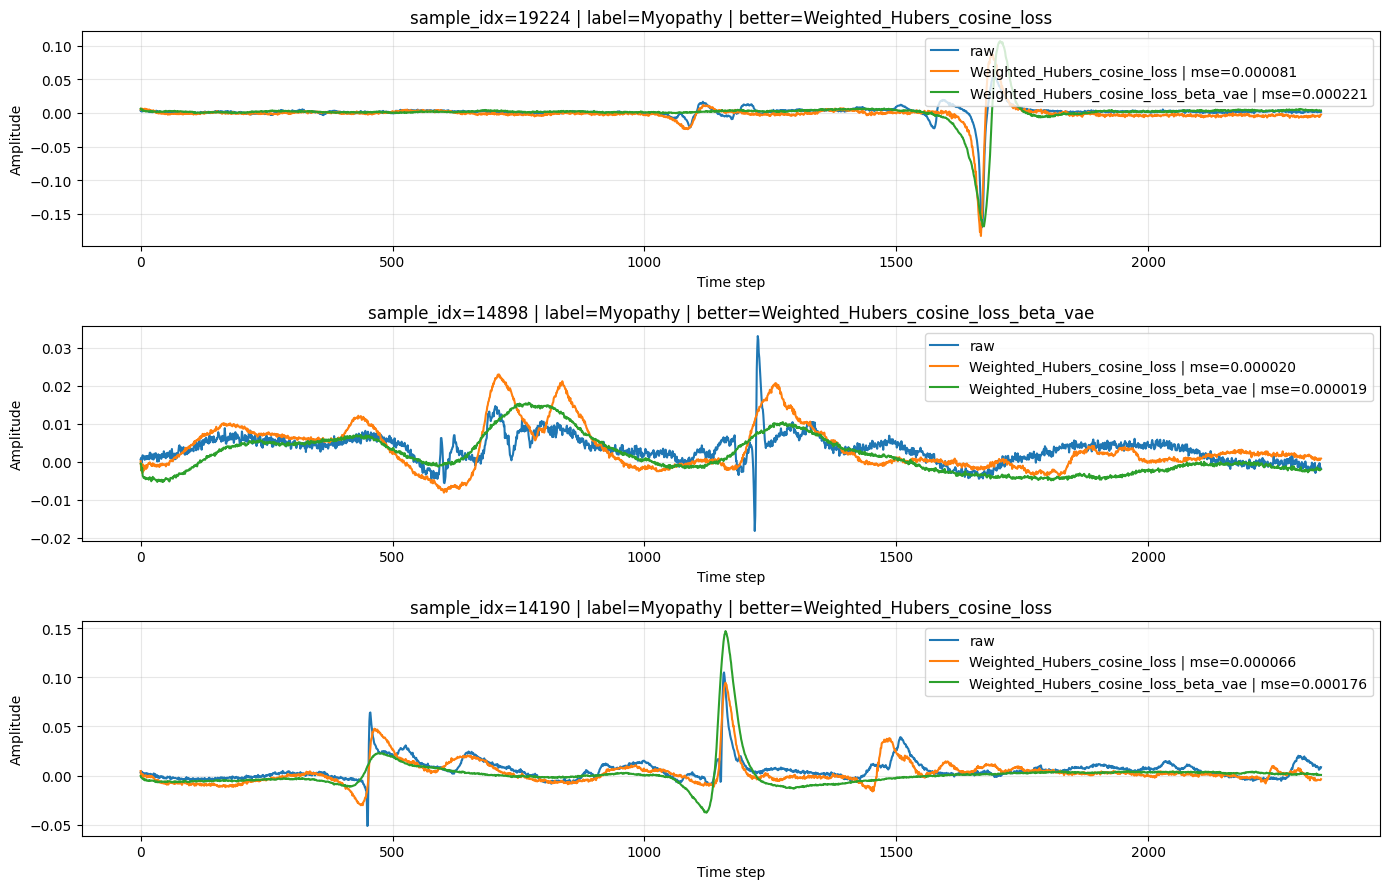

In [9]:

selected_indices = sample_indices_for_label(
    dataset=dataset,
    target_label=TARGET_LABEL,
    n_samples=NUM_RANDOM_SAMPLES,
    seed=RANDOM_SEED,
)

raw_batch, labels = fetch_samples(dataset, selected_indices)

print("Selected indices:", selected_indices)
print("Selected label:", TARGET_LABEL)
print("Raw batch shape:", tuple(raw_batch.shape))

recon_batch_a = reconstruct_batch(
    model=model_a,
    batch_x=raw_batch,
    device=DEVICE,
    deterministic=DETERMINISTIC_RECON,
)
recon_batch_b = reconstruct_batch(
    model=model_b,
    batch_x=raw_batch,
    device=DEVICE,
    deterministic=DETERMINISTIC_RECON,
)

print(f"{CHECKPOINT_LABEL_A} recon batch shape:", tuple(recon_batch_a.shape))
print(f"{CHECKPOINT_LABEL_B} recon batch shape:", tuple(recon_batch_b.shape))

comparison_df = build_sample_comparison_table(
    raw_batch=raw_batch,
    recon_a=recon_batch_a,
    recon_b=recon_batch_b,
    indices=selected_indices,
    labels=labels,
    label_a=CHECKPOINT_LABEL_A,
    label_b=CHECKPOINT_LABEL_B,
)
display(comparison_df)

plot_checkpoint_comparison(
    raw_batch=raw_batch,
    recon_a=recon_batch_a,
    recon_b=recon_batch_b,
    indices=selected_indices,
    labels=labels,
    label_a=CHECKPOINT_LABEL_A,
    label_b=CHECKPOINT_LABEL_B,
)


## Optional: save the current comparison figure


In [ ]:
SAVE_FIG = False
SAVE_PATH = Path("reconstruction_examples.png")

if SAVE_FIG:
    SAVE_PATH = resolve_path(SAVE_PATH, repo_root)
    plt.gcf().savefig(SAVE_PATH, dpi=150, bbox_inches="tight")
    print("Saved:", SAVE_PATH)

: 